# Matplotlib

Matplotlib es el paquete básico para la creación de gráficos en Python científico.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Conceptos de Matplotlib

Matplotlib fue diseñado con los siguientes objetivos (según la documentación):

* Las gráficas deben tener aspecto excelente — calidad de publicación (por ejemplo, antialiasing)
* Salida en Postscript/PDF para inclusión en documentos TeX
* Integrable en una interfaz gráfica para desarrollo de aplicaciones
* El código debe ser fácil de entender y extender
* Hacer gráficas debe ser sencillo

Matplotlib se usa principalmente para datos 2-D, aunque existe soporte básico para superficies 3-D.


### Galería

Matplotlib tiene una gran galería en su web — busca algo parecido a lo que quieres hacer y úsalo como punto de partida:

https://matplotlib.org/stable/gallery/index.html

### Importar

Existen varias interfaces para matplotlib (ver https://matplotlib.org/3.1.1/faq/index.html)

Ideas básicas:

* `matplotlib` es el paquete completo
* `matplotlib.pyplot` es un módulo dentro de matplotlib que proporciona acceso sencillo a las rutinas de trazado
* `pylab` combina pyplot y numpy en un único namespace para dar una interfaz tipo MatLab. Deberías evitarlo — podría eliminarse en el futuro.

Hay varios módulos que amplían su comportamiento, p.ej. `basemap` para trazar en una esfera, `mplot3d` para superficies 3-D.

### Anatomía de una figura

Las figuras son el objeto de más alto nivel y pueden incluir múltiples ejes
![](anatomy1.png)

(figura de: http://matplotlib.org/faq/usage_faq.html#parts-of-a-figure )

# Trazado básico

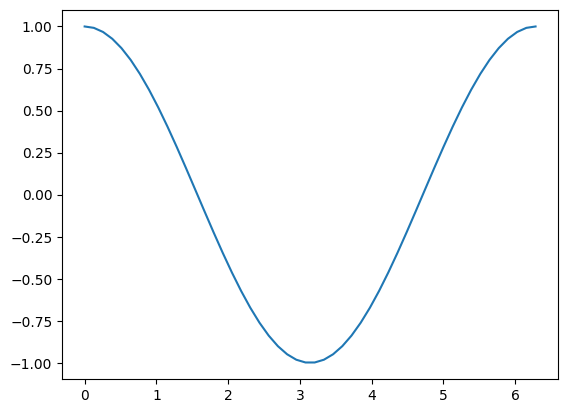

In [2]:
x = np.linspace(0.0, 2.0*np.pi, 50)
y = np.cos(x)
plt.plot(x,y)

`plot()` es el comando más básico. No obstante, es una buena práctica usar `plt.subplots()` para tener acceso al objeto  `Figure` y el objeto `Axis`, y poder modificarlos. También podemos utilizar `figure()` para obtener acceso al objeto `Figure`. 

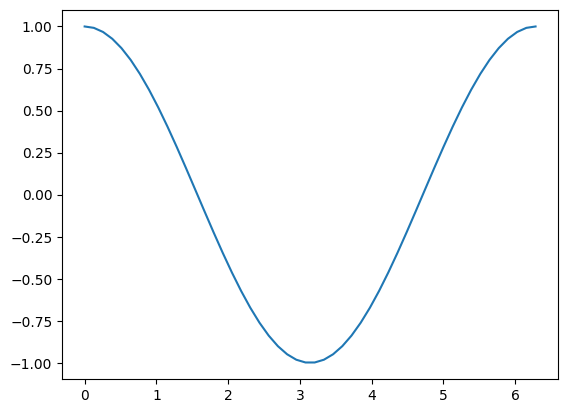

In [3]:
fig, ax = plt.subplots()

ax.plot(x, y)


Con matplotlib, podemos modificar todas las partes de la gráfica: ejes, etiquetas, leyendas, etc. Las etiquetas de los ejes, los títulos o las leyendas pueden incluir notación LaTeX para incluir fórmulas matemáticas.

```{admonition} :class: tip
Podemos dibujar 2 líneas en la misma gráfica llamando a `plot` dos veces. Podemos crear una gráfica con `sin(x)` y `cos(x)` dibujadas.
```

(0.0, 6.283185307179586)

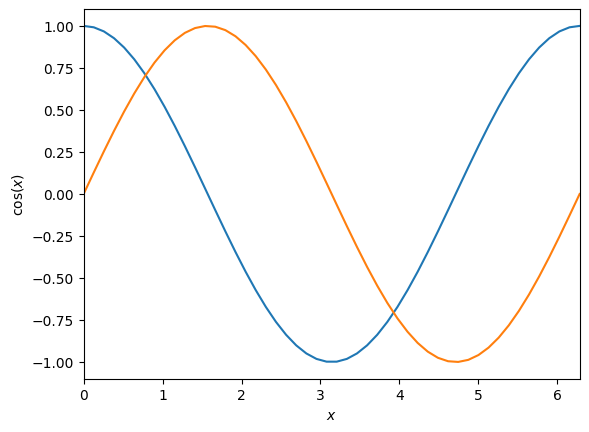

In [6]:
fig, ax = plt.subplots()

ax.plot(x, y)
ax.plot(x, np.sin(x))

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\cos(x)$")
ax.set_xlim(0, 2*np.pi)

También podemos usar símbolos en lugar de líneas con facilidad — y etiquetarlos con leyendas.

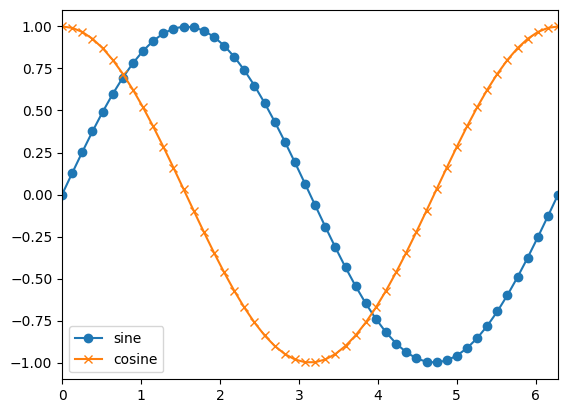

In [7]:
fig, ax = plt.subplots()

ax.plot(x, np.sin(x), marker="o", label="sine")
ax.plot(x, np.cos(x), marker="x", label="cosine")
ax.set_xlim(0.0, 2.0*np.pi)
ax.legend()

```{tip}
Igual que pasaba en MatLab, podemos especificar un estilo básico usando una "format string" (ver https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.plot.html)

Tiene la forma `'[marcador][línea][color]'`
```

Aquí podemos cambiar el estilo de línea y el grosor.

In [ ]:
fig, ax = plt.subplots()
ax.plot(x, np.sin(x), linestyle="--", linewidth=3.0)
ax.plot(x, np.cos(x), linestyle="-")

También existen estilos predefinidos que pueden usarse. Para ello, debes seleccionar el estilo al crear la figura para que tenga efecto.

In [ ]:
plt.style.available

In [ ]:
plt.style.use("fivethirtyeight")

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x, np.sin(x), linestyle="--", linewidth=3.0)
ax.plot(x, np.cos(x), linestyle="-")
ax.set_xlim(0.0, 2.0*np.pi)

In [ ]:
plt.style.use("default")

Para una descripción completa de los campos a modificar de las gráficas, así como de todas las opciones, se puede consultar la documentación oficial de MatPlotLib https://matplotlib.org/stable/api/ Aquí nos hemos limitado a ilustrar algunos ejemplos.

# Múltiples plots


Hay una amplia variedad de métodos para colocar múltiples ejes en una cuadrícula. Veremos el método más simple.

El método `add_subplot()` que hemos estado usando puede tomar 3 números: número de filas, número de columnas y el índice actual.

In [ ]:
fig = plt.figure()

ax1 = fig.add_subplot(211) ## También se podría haber hecho: fig, (ax1,ax2) = plt.subplots(2,1)

x = np.linspace(0,5, 100)
ax1.plot(x, x**3 - 4*x)
ax1.set_xlabel("x")
ax1.set_ylabel(r"$x^3 - 4x$", fontsize="large")

ax2 = fig.add_subplot(212)

ax2.plot(x, np.exp(-x**2))
ax2.set_xlabel("x")
ax2.set_ylabel("Gaussian")

# log scale
ax2.set_yscale("log")

# tight_layout() makes sure things don't overlap
fig.tight_layout()

# Gráficos 2-D adicionales

Algunos tipos de gráficas adicionales son:
* Gráficas de dispersión (scatter plots) .scatter()
* Gráficas de barras .bar()
* Gráficas de sectores (pie charts) .pie()
* Gráficas de cajas (box plots) .boxplot()
* Histogramas .hist()
* Gráficas de contorno .contour()
* Mapas de calor (heatmaps) .imshow()
* Gráficas de error (error bars) .errorbar()
* Gráficas de puntos con meshgrid()

La documentación oficial de Matplotlib tiene muchos ejemplos de estos tipos de gráficas: https://matplotlib.org/stable/plot_types/index.html

Vamos a ver a continuación algunos ejemplos simples


## Meshgrids

Los conjuntos de datos 2-d consisten en pares (x, y) y un valor asociado a ese punto. Aquí creamos una gaussiana 2-d, usando `meshgrid()` para definir una rejilla rectangular de puntos.

In [ ]:
def g(x, y):
    return np.exp(-((x-0.5)**2)/0.1**2 - ((y-0.5)**2)/0.2**2)

N = 100

x = np.linspace(0.0, 1.0, N)
y = x.copy()

xv, yv = np.meshgrid(x, y)

## Mapa de calor

Un gráfico de tipo 'heatmap' asigna colores a los valores de los datos. Mucho trabajo se ha dedicado en las versiones recientes de matplotlib para definir mapas de color que funcionen bien para daltonismo y para impresión en blanco y negro.

In [ ]:
fig, ax = plt.subplots()

im = ax.imshow(g(xv, yv), origin="lower")
fig.colorbar(im, ax=ax)

## Contornos

A veces queremos mostrar solo las líneas de contorno — como en un mapa topográfico. La función `contour()` hace esto por nosotros.

In [ ]:
fig, ax = plt.subplots()

contours = ax.contour(g(xv, yv))
ax.axis("equal")   # ajusta el tamaño de la imagen para que las longitudes x e y sean iguales


Los contornos pueden etiquetarse usando `ax.clabel()`.


## Barras de error

En experimentos, a menudo tenemos errores asociados con los valores de $y$. Aquí creamos algunos datos y añadimos ruido, luego los graficamos con sus errores.

In [ ]:
def y_experiment(a1, a2, sigma, x):
    """ return the experimental data in a linear + random fashion a1
        is the intercept, a2 is the slope, and sigma is the error """

    N = len(x)

    # standard_normal gives samples from the "standard normal" distribution
    rng = np.random.default_rng()
    r = rng.standard_normal(N)
    y = a1 + a2*x + sigma*r
    return y

N = 40
x = np.linspace(0.0, 100.0, N)
sigma = 25.0*np.ones(N)
y = y_experiment(10.0, 3.0, sigma, x)

In [ ]:
fig, ax = plt.subplots()
ax.errorbar(x, y, yerr=sigma, fmt="o")

## Histogramas

Aquí generamos muchos números gaussianos normalizados y hacemos un histograma. La distribución de probabilidad debería coincidir con
$$y(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-x^2/(2\sigma^2)}$$

Text(0.5, 0, 'x')

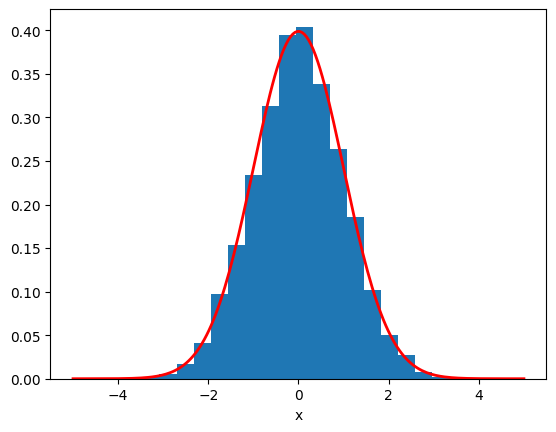

In [ ]:
N = 10000
rng = np.random.default_rng()
r = rng.standard_normal(N)

fig, ax = plt.subplots()
ax.hist(r, density=True, bins=20)

x = np.linspace(-5,5,200)
sigma = 1.0
ax.plot(x, np.exp(-x**2/(2*sigma**2)) / (sigma*np.sqrt(2.0*np.pi)),
        c="r", lw=2)
ax.set_xlabel("x")

# Anotaciones

Añadir texto y anotaciones es sencillo.

In [ ]:
xx = np.linspace(0, 2.0*np.pi, 1000)

In [ ]:
fig, ax = plt.subplots()
ax.plot(xx, np.sin(xx))
ax.text(np.pi/2, np.sin(np.pi/2), r"maximum")

También podemos desactivar las líneas superior y derecha.

In [ ]:
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')                                           
ax.yaxis.set_ticks_position('left') 
fig

Las anotaciones con una flecha también son posibles.

Text(0.05, 0.05, 'a polar annotation')

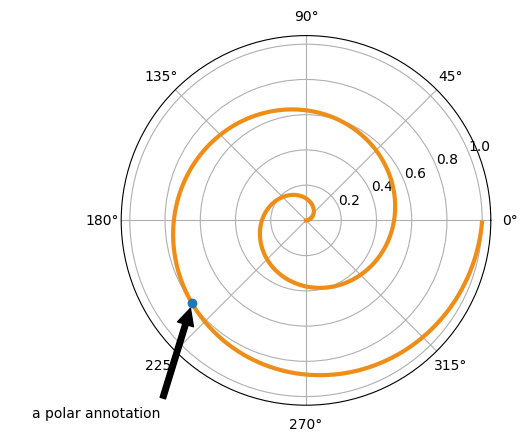

In [ ]:
#example from http://matplotlib.org/examples/pylab_examples/annotation_demo.html
fig = plt.figure()
ax = fig.add_subplot(111, projection='polar')
r = np.arange(0, 1, 0.001)
theta = 2*2*np.pi*r
line, = ax.plot(theta, r, color='#ee8d18', lw=3)

ind = 800
thisr, thistheta = r[ind], theta[ind]
ax.plot([thistheta], [thisr], 'o')
ax.annotate('a polar annotation',
            xy=(thistheta, thisr),  # theta, radius
            xytext=(0.05, 0.05),    # fraction, fraction
            textcoords='figure fraction',
            arrowprops=dict(facecolor='black', shrink=0.05),
            horizontalalignment='left',
            verticalalignment='bottom',
            )

# Graficar datos desde un fichero

`numpy.loadtxt()` ofrece una forma fácil de leer columnas de datos desde un fichero ASCII.

In [12]:
data = np.loadtxt("test1.exact.128.out")
print(data.shape)

(128, 8)


También podemos cargar datos utilizando np.genfromtxt('nombrefichero.ext',delimiter=',') si el fichero tiene un formato más complicado (p.ej. con comentarios o datos faltantes).

In [13]:
data = np.genfromtxt("test1.exact.128.out")
print(data.shape)

(128, 8)


findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

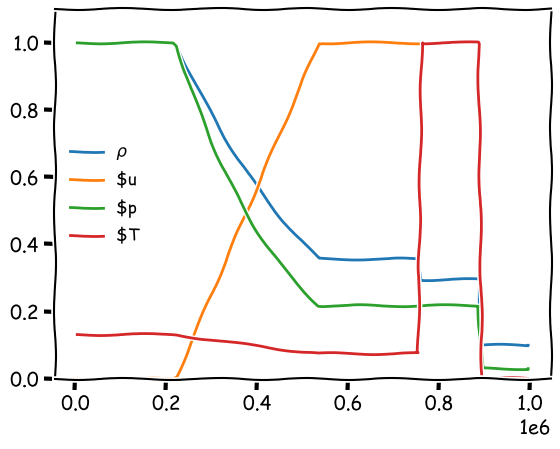

In [16]:
fig, ax = plt.subplots()
ax.plot(data[:,1], data[:,2]/np.max(data[:,2]), label=r"$\rho$")
ax.plot(data[:,1], data[:,3]/np.max(data[:,3]), label=r"$u")
ax.plot(data[:,1], data[:,4]/np.max(data[:,4]), label=r"$p")
ax.plot(data[:,1], data[:,5]/np.max(data[:,5]), label=r"$T")
ax.set_ylim(0,1.1)
ax.legend(frameon=False, fontsize=12)

Si hacemos cambios en los datos, podemos guardarlos utilizando `np.savetxt('nombrefichero.ext', data, delimiter=',')`

# Diversión final

Si quieres que las gráficas tengan un aspecto dibujado a mano al estilo xkcd, vuelve a ejecutar estos ejemplos después de hacer
plt.xkcd()

In [15]:
plt.xkcd()